# Safaricom (SCOM) Equity Analysis: Risk, Return & Portfolio Analytics

**Author:** Siraji Ali  
**Date:** 2026  
**Tools:** Python, pandas, NumPy, matplotlib, seaborn  
**Data:** Safaricom PLC daily OHLCV data (March 2024 – March 2026, NSE)  

---

## Executive Summary

This analysis evaluates Safaricom PLC (SCOM) — the most liquid stock on the Nairobi Securities Exchange  from the perspective of an **investment analyst assessing whether to include SCOM in a client portfolio**.

The analysis covers:
1. **Return & risk profiling** — how has SCOM performed on a risk-adjusted basis?
2. **Volatility regime analysis** — when is SCOM most risky, and what drives it?
3. **Value at Risk (VaR)** — what is the maximum expected daily loss at 95% and 99% confidence?
4. **Technical structure** — where are key support/resistance levels and what do momentum indicators suggest?
5. **Investment recommendation** — actionable output for a portfolio manager

### Key Findings
- SCOM delivered a total return of 6.3% over 2 years (annualized ~3.0%), **underperforming** the risk-free rate (91-day T-bill ~10%)
- Annualized volatility of 21.7% with a maximum drawdown of -22.7%
- Negative Sharpe ratio (-0.32) indicates the stock has not compensated investors for the risk taken
- 1-day VaR (95%) of -2.05% means a KES 10M position could lose up to KES 205,000 on a bad day

---

## 1. Environment Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('Environment ready.')

Environment ready.


In [3]:
df = pd.read_csv('safaricom_stock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset: {len(df)} trading days')
print(f'Period: {df["Date"].dt.date.iloc[0]} to {df["Date"].dt.date.iloc[-1]}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nPrice Range: KES {df["Close"].min():.2f} – KES {df["Close"].max():.2f}')
print(f'Average Daily Volume: {df["Volume"].mean():,.0f} shares')
print(f'Average Daily Value Traded: ~KES {(df["Volume"] * df["Close"]).mean():,.0f}')



Dataset: 523 trading days
Period: 2024-03-18 to 2026-03-18
Missing values: 0

Price Range: KES 23.34 – KES 36.24
Average Daily Volume: 9,148,016 shares
Average Daily Value Traded: ~KES 263,968,081


## 2. Return Analysis

Returns are the language of investment analysis. We compute daily, cumulative, and rolling returns to understand SCOM's performance trajectory.

In [4]:
# Compute returns
df['Daily_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

# Key return metrics
total_return = df['Cumulative_Return'].iloc[-1]
n_days = len(df)
annualized_return = (1 + total_return) ** (252 / n_days) - 1
daily_vol = df['Daily_Return'].std()
annual_vol = daily_vol * np.sqrt(252)
risk_free = 0.10  # Kenya 91-day T-bill rate (~10%)
sharpe = (annualized_return - risk_free) / annual_vol

# Max drawdown
rolling_max = df['Close'].cummax()
drawdown = df['Close'] / rolling_max - 1
max_drawdown = drawdown.min()
max_dd_date = df.loc[drawdown.idxmin(), 'Date']

print('=' * 55)
print('SAFARICOM (SCOM) — RETURN & RISK PROFILE')
print('=' * 55)
print(f'\nTotal Return:           {total_return:>10.2%}')
print(f'Annualized Return:      {annualized_return:>10.2%}')
print(f'Risk-Free Rate (T-bill):{risk_free:>10.2%}')
print(f'Excess Return:          {annualized_return - risk_free:>10.2%}')
print(f'\nDaily Volatility:       {daily_vol:>10.4f}')
print(f'Annualized Volatility:  {annual_vol:>10.2%}')
print(f'Sharpe Ratio:           {sharpe:>10.3f}')
print(f'\nMaximum Drawdown:       {max_drawdown:>10.2%}')
print(f'Max Drawdown Date:      {max_dd_date.date()}')
print(f'Skewness:               {df["Daily_Return"].skew():>10.3f}')
print(f'Kurtosis:               {df["Daily_Return"].kurtosis():>10.3f}')
print(f'\nInterpretation:')
print(f'The negative Sharpe ratio means SCOM has not compensated investors')
print(f'for the risk taken relative to risk-free T-bills. An investor would')
print(f'have earned more with zero risk by holding government securities.')

SAFARICOM (SCOM) — RETURN & RISK PROFILE

Total Return:                6.30%
Annualized Return:           2.99%
Risk-Free Rate (T-bill):    10.00%
Excess Return:              -7.01%

Daily Volatility:           0.0137
Annualized Volatility:      21.71%
Sharpe Ratio:               -0.323

Maximum Drawdown:          -22.66%
Max Drawdown Date:      2024-08-09
Skewness:                    0.237
Kurtosis:                    0.453

Interpretation:
The negative Sharpe ratio means SCOM has not compensated investors
for the risk taken relative to risk-free T-bills. An investor would
have earned more with zero risk by holding government securities.


### 2.1 Price & Cumulative Return Chart

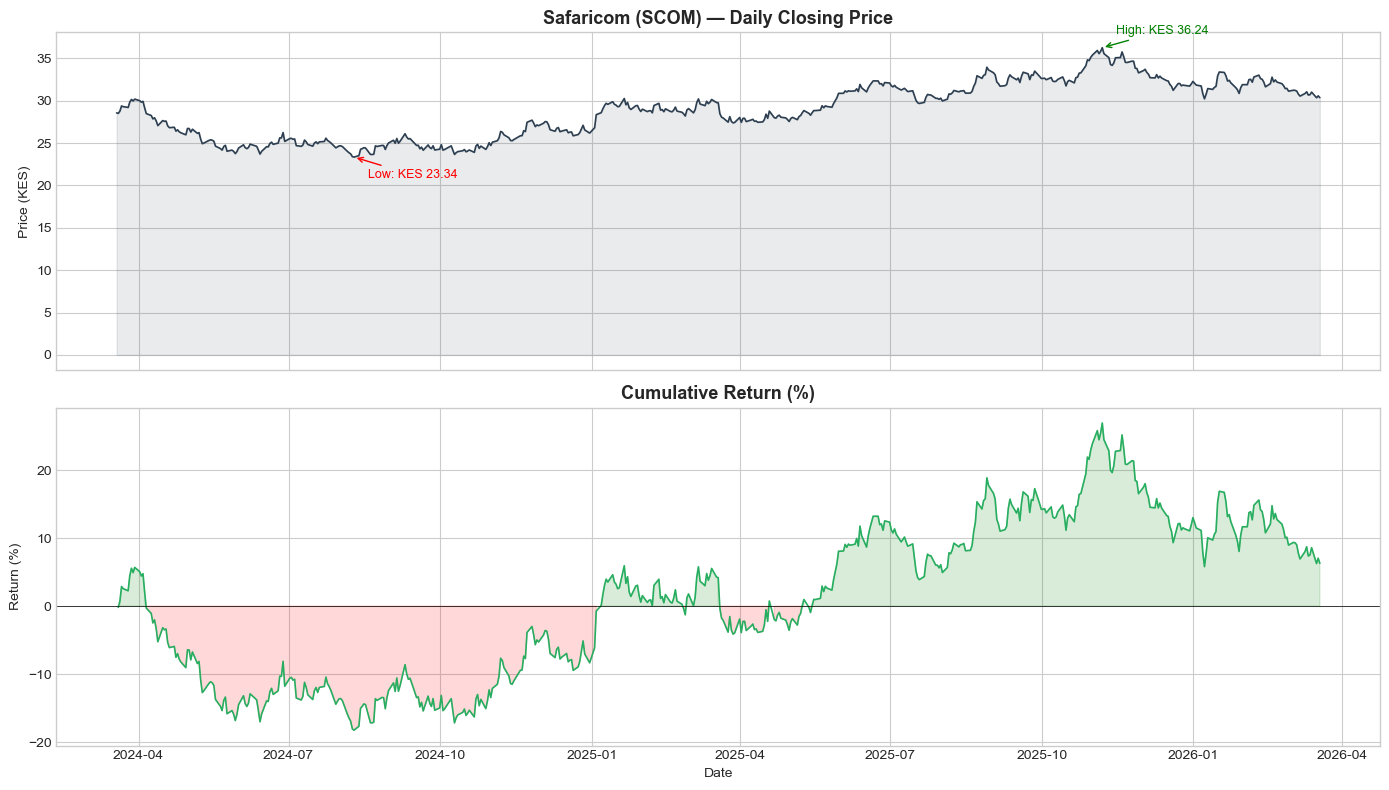

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price chart
axes[0].plot(df['Date'], df['Close'], color='#2c3e50', linewidth=1.2)
axes[0].set_title('Safaricom (SCOM) — Daily Closing Price', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Price (KES)')
axes[0].fill_between(df['Date'], df['Close'], alpha=0.1, color='#2c3e50')

# Mark high and low
high_idx = df['Close'].idxmax()
low_idx = df['Close'].idxmin()
axes[0].annotate(f'High: KES {df["Close"].max():.2f}', 
                 xy=(df.loc[high_idx, 'Date'], df.loc[high_idx, 'Close']),
                 xytext=(10, 10), textcoords='offset points', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='green'), color='green')
axes[0].annotate(f'Low: KES {df["Close"].min():.2f}', 
                 xy=(df.loc[low_idx, 'Date'], df.loc[low_idx, 'Close']),
                 xytext=(10, -15), textcoords='offset points', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='red'), color='red')

# Cumulative return
axes[1].plot(df['Date'], df['Cumulative_Return'] * 100, color='#27ae60', linewidth=1.2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].fill_between(df['Date'], df['Cumulative_Return'] * 100, 
                     where=df['Cumulative_Return'] >= 0, alpha=0.15, color='green')
axes[1].fill_between(df['Date'], df['Cumulative_Return'] * 100, 
                     where=df['Cumulative_Return'] < 0, alpha=0.15, color='red')
axes[1].set_title('Cumulative Return (%)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Return (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('01_price_and_returns.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Return Distribution — Is SCOM Normally Distributed?

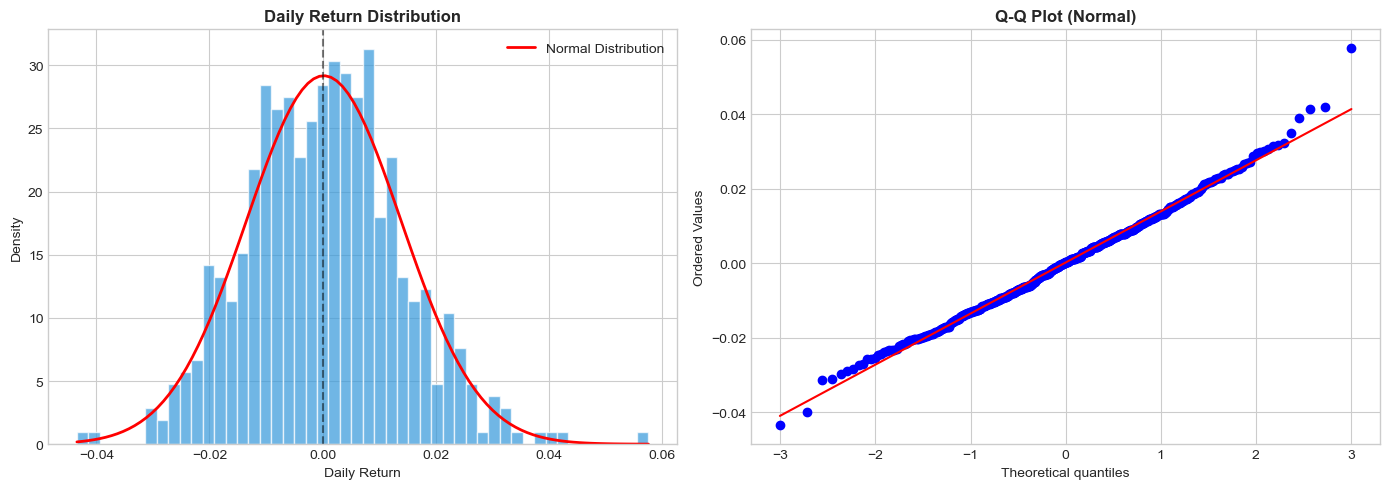

Jarque-Bera test: statistic=9.01, p-value=0.0111
Skewness: 0.237 (positive = right tail risk)
Kurtosis: 0.453 (>0 = fatter tails than normal)

This matters because VaR models that assume normality will
underestimate tail risk. Portfolio managers need to account for this.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal overlay
returns = df['Daily_Return'].dropna()
axes[0].hist(returns, bins=50, density=True, alpha=0.7, color='#3498db', edgecolor='white')
x = np.linspace(returns.min(), returns.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 
             'r-', linewidth=2, label='Normal Distribution')
axes[0].set_title('Daily Return Distribution', fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

# QQ plot
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal)', fontweight='bold')

plt.tight_layout()
plt.savefig('02_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Normality test
jb_stat, jb_pval = stats.jarque_bera(returns)
print(f'Jarque-Bera test: statistic={jb_stat:.2f}, p-value={jb_pval:.4f}')
print(f'Skewness: {returns.skew():.3f} (positive = right tail risk)')
print(f'Kurtosis: {returns.kurtosis():.3f} (>0 = fatter tails than normal)')
print(f'\nThis matters because VaR models that assume normality will')
print(f'underestimate tail risk. Portfolio managers need to account for this.')

### 2.3 Quarterly Performance Breakdown

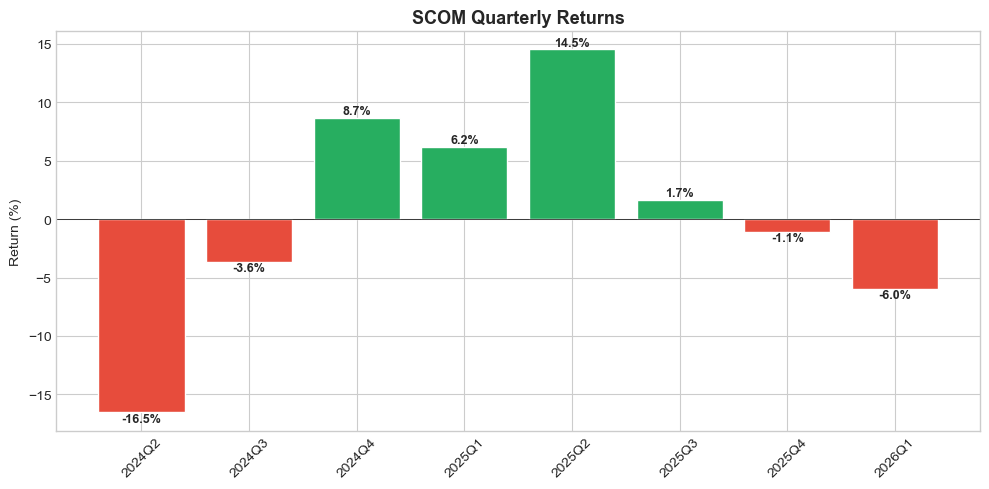

In [7]:
# Quarterly returns for performance attribution
df['Quarter'] = df['Date'].dt.to_period('Q')
quarterly = df.groupby('Quarter').agg(
    Open=('Open', 'first'),
    Close=('Close', 'last'),
    High=('High', 'max'),
    Low=('Low', 'min'),
    Avg_Volume=('Volume', 'mean')
)
quarterly['Return'] = quarterly['Close'].pct_change()
quarterly['Range'] = (quarterly['High'] - quarterly['Low']) / quarterly['Low'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if r >= 0 else '#e74c3c' for r in quarterly['Return'].values]
bars = ax.bar(quarterly.index.astype(str), quarterly['Return'] * 100, color=colors, edgecolor='white')

for bar, val in zip(bars, quarterly['Return'].values):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + (0.3 if val >= 0 else -0.8),
                f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('SCOM Quarterly Returns', fontweight='bold', fontsize=13)
ax.set_ylabel('Return (%)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('03_quarterly_returns.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['Quarter'], inplace=True)

## 3. Volatility Analysis

Volatility is not constant — it clusters. Understanding **when** SCOM is most volatile helps portfolio managers time entries and adjust position sizes.

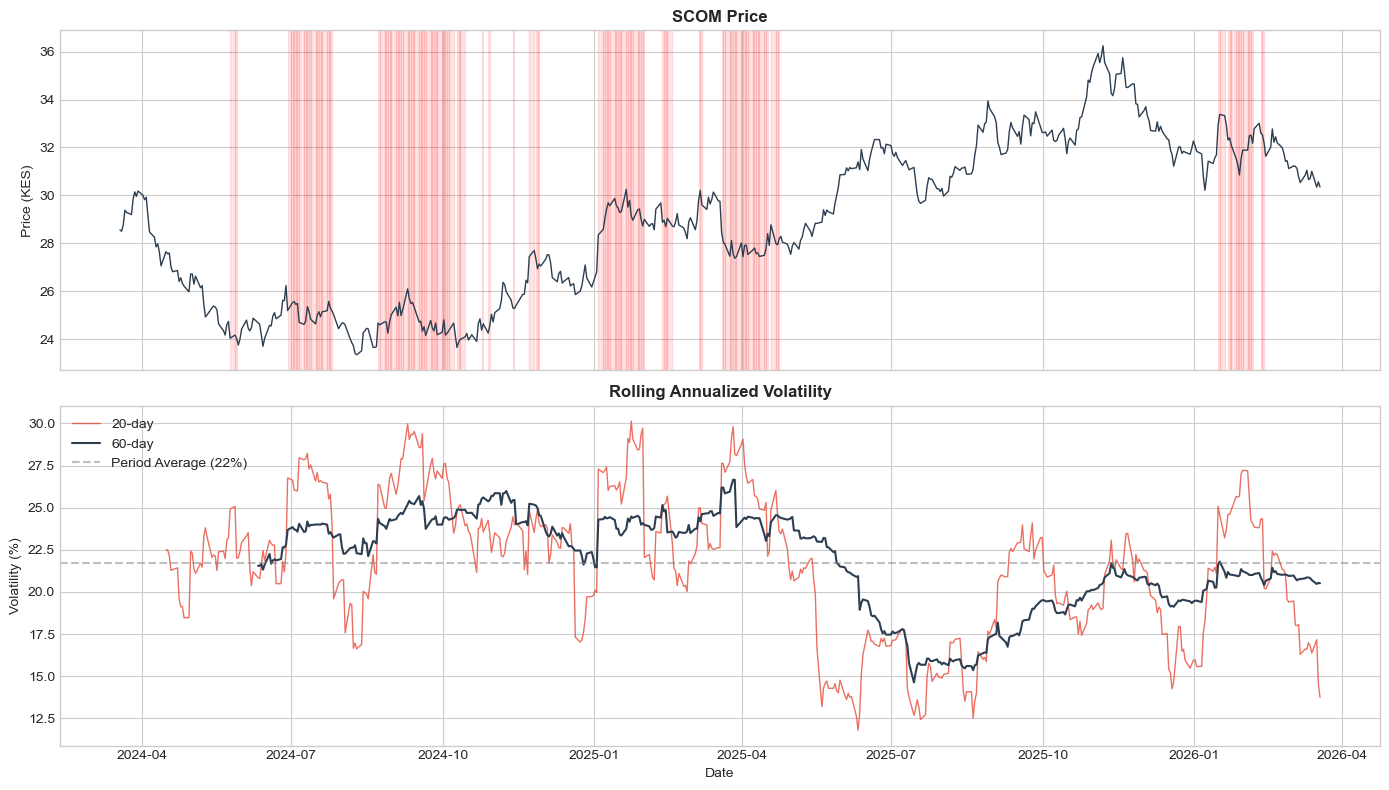

Average annualized volatility: 21.7%
Current 20-day volatility: 13.7%
High-volatility threshold (75th percentile): 24.2%

Red shaded areas show periods of elevated volatility.
Notice how volatility clusters — high-vol periods tend to persist.
This is volatility clustering, a well-documented market phenomenon.


In [8]:
# Rolling volatility (annualized)
df['Vol_20d'] = df['Daily_Return'].rolling(20).std() * np.sqrt(252) * 100
df['Vol_60d'] = df['Daily_Return'].rolling(60).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price with volatility regimes
axes[0].plot(df['Date'], df['Close'], color='#2c3e50', linewidth=1)
axes[0].set_title('SCOM Price', fontweight='bold')
axes[0].set_ylabel('Price (KES)')

# Rolling volatility
axes[1].plot(df['Date'], df['Vol_20d'], color='#e74c3c', linewidth=1, label='20-day', alpha=0.8)
axes[1].plot(df['Date'], df['Vol_60d'], color='#2c3e50', linewidth=1.5, label='60-day')
axes[1].axhline(y=annual_vol*100, color='gray', linestyle='--', alpha=0.5, label=f'Period Average ({annual_vol:.0%})')
axes[1].set_title('Rolling Annualized Volatility', fontweight='bold')
axes[1].set_ylabel('Volatility (%)')
axes[1].legend()
axes[1].set_xlabel('Date')

# Shade high-vol periods
vol_threshold = df['Vol_20d'].quantile(0.75)
high_vol = df['Vol_20d'] > vol_threshold
for i in range(len(df)):
    if high_vol.iloc[i]:
        axes[0].axvspan(df['Date'].iloc[i], df['Date'].iloc[min(i+1, len(df)-1)], 
                        alpha=0.1, color='red')

plt.tight_layout()
plt.savefig('04_volatility_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average annualized volatility: {annual_vol:.1%}')
print(f'Current 20-day volatility: {df["Vol_20d"].iloc[-1]:.1f}%')
print(f'High-volatility threshold (75th percentile): {vol_threshold:.1f}%')
print(f'\nRed shaded areas show periods of elevated volatility.')
print(f'Notice how volatility clusters — high-vol periods tend to persist.')
print(f'This is volatility clustering, a well-documented market phenomenon.')

## 4. Value at Risk (VaR) — Downside Risk Quantification

VaR answers a critical portfolio management question: **"What is the maximum I can expect to lose on a bad day?"**

We compute VaR using three methods:
1. **Historical** — directly from the return distribution (no assumptions)
2. **Parametric (Gaussian)** — assumes normal distribution
3. **Conditional VaR (CVaR/Expected Shortfall)** — average loss *beyond* VaR (what happens in the worst cases)

In [9]:
returns = df['Daily_Return'].dropna()
position_size = 10_000_000  # KES 10M position

# Historical VaR
var_95_hist = np.percentile(returns, 5)
var_99_hist = np.percentile(returns, 1)

# Parametric VaR (assumes normality)
var_95_param = stats.norm.ppf(0.05, returns.mean(), returns.std())
var_99_param = stats.norm.ppf(0.01, returns.mean(), returns.std())

# CVaR (Expected Shortfall)
cvar_95 = returns[returns <= var_95_hist].mean()
cvar_99 = returns[returns <= var_99_hist].mean()

print('=' * 60)
print(f'VALUE AT RISK — KES {position_size/1e6:.0f}M SCOM POSITION')
print('=' * 60)
print(f'\n{"Method":<25} {"95% Confidence":>17} {"99% Confidence":>17}')
print('-' * 60)
print(f'{"Historical VaR":<25} {var_95_hist:>16.2%} {var_99_hist:>16.2%}')
print(f'{"Parametric VaR":<25} {var_95_param:>16.2%} {var_99_param:>16.2%}')
print(f'{"CVaR (Exp. Shortfall)":<25} {cvar_95:>16.2%} {cvar_99:>16.2%}')
print(f'\n{"KES Impact":<25} {"95% Confidence":>17} {"99% Confidence":>17}')
print('-' * 60)
print(f'{"Max Daily Loss (Hist)":<25} {"KES {:>12,.0f}".format(abs(var_95_hist)*position_size)} {"KES {:>12,.0f}".format(abs(var_99_hist)*position_size)}')
print(f'{"Avg Tail Loss (CVaR)":<25} {"KES {:>12,.0f}".format(abs(cvar_95)*position_size)} {"KES {:>12,.0f}".format(abs(cvar_99)*position_size)}')
print(f'\nInterpretation:')
print(f'On 95% of trading days, a KES 10M position will not lose more than')
print(f'KES {abs(var_95_hist)*position_size:,.0f}. However, on the worst 5% of days, the average')
print(f'loss is KES {abs(cvar_95)*position_size:,.0f} (CVaR).')
print(f'\nThe parametric VaR underestimates risk slightly because SCOM returns')
print(f'have fatter tails than a normal distribution. Use Historical VaR for')
print(f'more conservative risk estimates.')

VALUE AT RISK — KES 10M SCOM POSITION

Method                       95% Confidence    99% Confidence
------------------------------------------------------------
Historical VaR                      -2.05%           -2.88%
Parametric VaR                      -2.23%           -3.16%
CVaR (Exp. Shortfall)               -2.60%           -3.40%

KES Impact                   95% Confidence    99% Confidence
------------------------------------------------------------
Max Daily Loss (Hist)     KES      205,443 KES      287,849
Avg Tail Loss (CVaR)      KES      260,075 KES      340,353

Interpretation:
On 95% of trading days, a KES 10M position will not lose more than
KES 205,443. However, on the worst 5% of days, the average
loss is KES 260,075 (CVaR).

The parametric VaR underestimates risk slightly because SCOM returns
have fatter tails than a normal distribution. Use Historical VaR for
more conservative risk estimates.


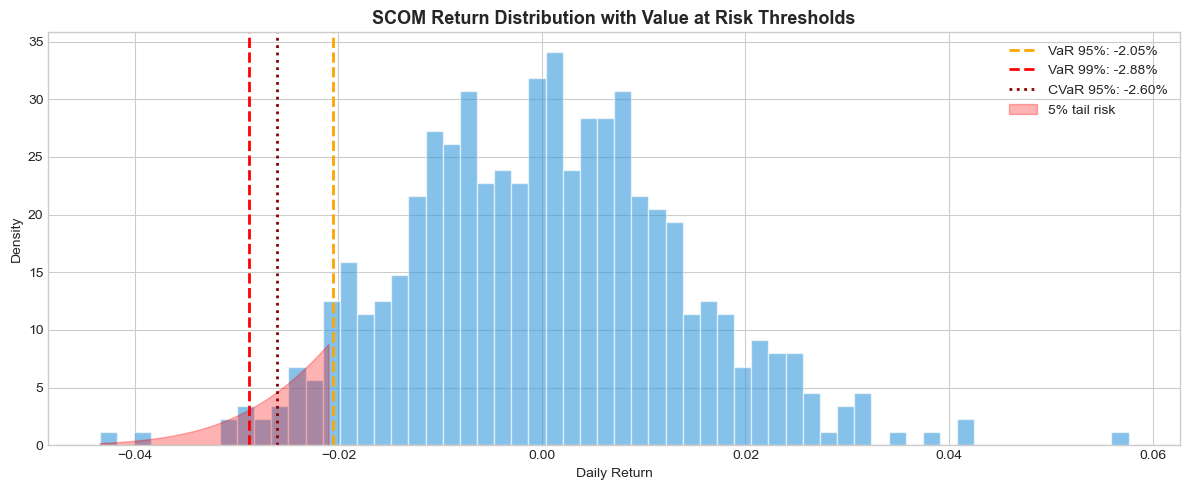

In [10]:
# VaR visualization
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(returns, bins=60, density=True, alpha=0.6, color='#3498db', edgecolor='white')

# Mark VaR thresholds
ax.axvline(x=var_95_hist, color='orange', linestyle='--', linewidth=2, 
           label=f'VaR 95%: {var_95_hist:.2%}')
ax.axvline(x=var_99_hist, color='red', linestyle='--', linewidth=2, 
           label=f'VaR 99%: {var_99_hist:.2%}')
ax.axvline(x=cvar_95, color='darkred', linestyle=':', linewidth=2, 
           label=f'CVaR 95%: {cvar_95:.2%}')

# Shade tail
ax.fill_between(x, 0, stats.norm.pdf(x, returns.mean(), returns.std()),
                where=x <= var_95_hist, alpha=0.3, color='red', label='5% tail risk')

ax.set_title('SCOM Return Distribution with Value at Risk Thresholds', fontweight='bold', fontsize=13)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('05_var_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Technical Analysis — Price Structure & Momentum

Technical indicators help identify entry/exit timing. We use three commonly used tools:
- **Moving Averages** — trend direction and support/resistance
- **Bollinger Bands** — volatility-based price channels
- **RSI** — momentum and overbought/oversold conditions

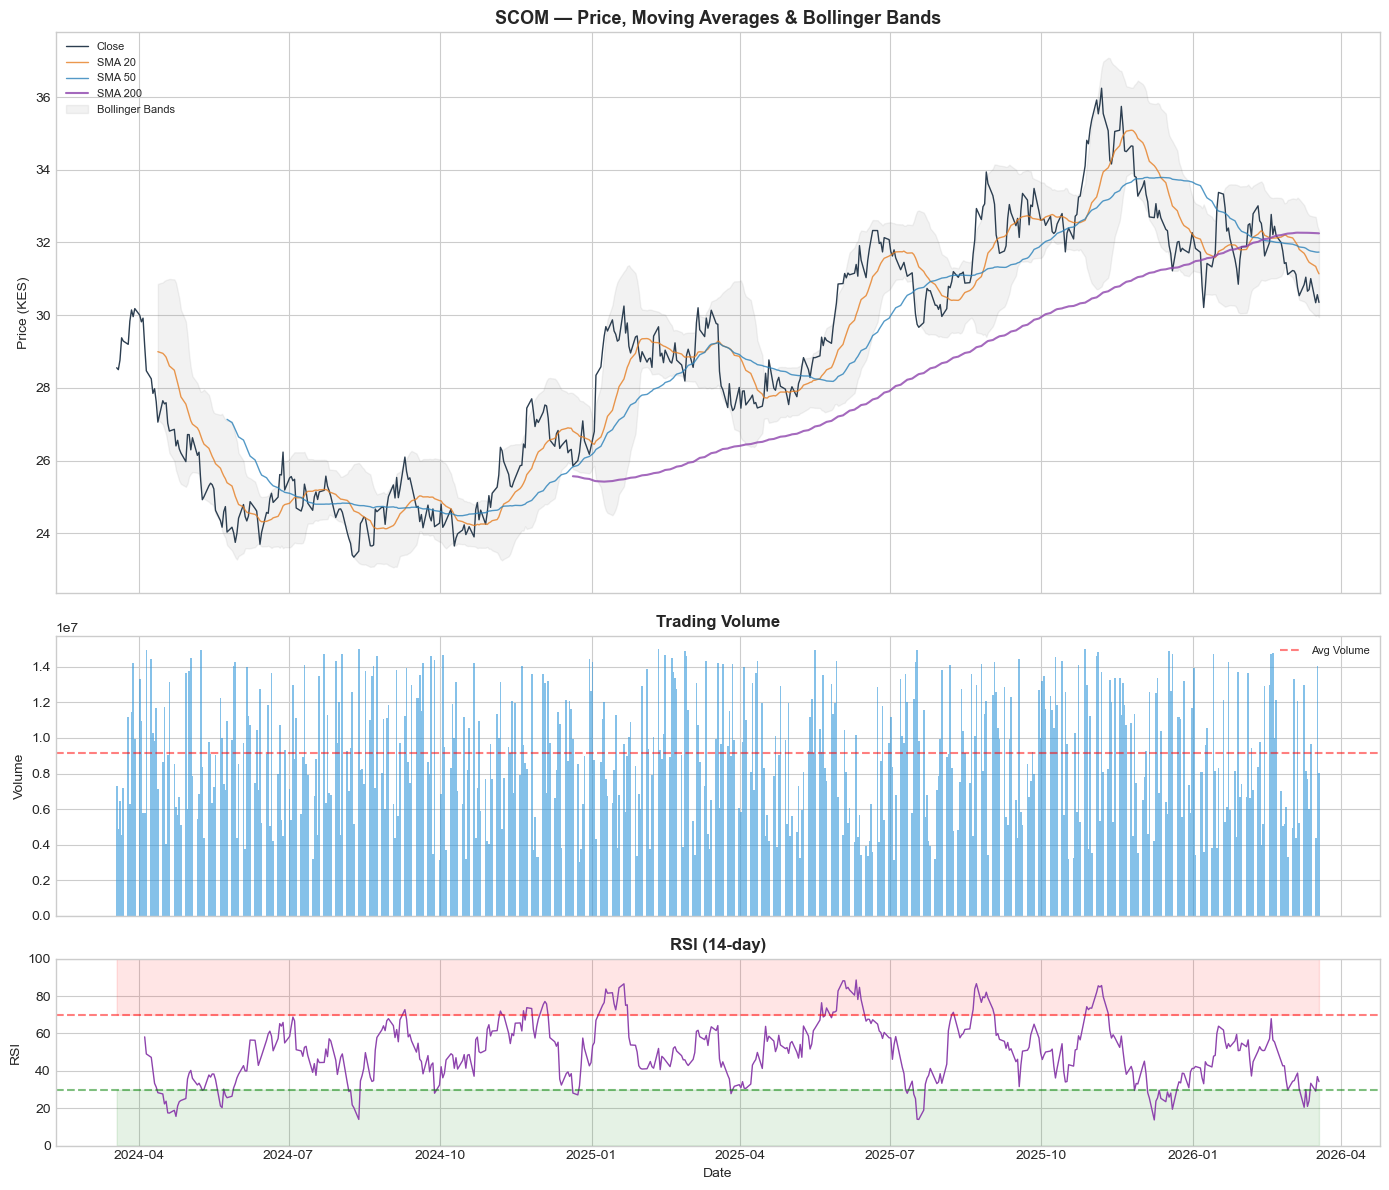

Current Technical Snapshot (2026-03-18):
  Close:   KES 30.35
  SMA 20:  KES 31.14 — price below
  SMA 50:  KES 31.74 — price below
  SMA 200: KES 32.25 — price below
  RSI:     34.2 — neutral


In [11]:
# Moving averages
df['SMA_20'] = df['Close'].rolling(20).mean()
df['SMA_50'] = df['Close'].rolling(50).mean()
df['SMA_200'] = df['Close'].rolling(200).mean()

# Bollinger Bands (20-day)
df['BB_mid'] = df['SMA_20']
df['BB_upper'] = df['BB_mid'] + 2 * df['Close'].rolling(20).std()
df['BB_lower'] = df['BB_mid'] - 2 * df['Close'].rolling(20).std()

# RSI (14-day)
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1.5, 1]})

# Price with MAs and Bollinger Bands
axes[0].plot(df['Date'], df['Close'], color='#2c3e50', linewidth=1, label='Close')
axes[0].plot(df['Date'], df['SMA_20'], color='#e67e22', linewidth=1, alpha=0.8, label='SMA 20')
axes[0].plot(df['Date'], df['SMA_50'], color='#2980b9', linewidth=1, alpha=0.8, label='SMA 50')
axes[0].plot(df['Date'], df['SMA_200'], color='#8e44ad', linewidth=1.5, alpha=0.8, label='SMA 200')
axes[0].fill_between(df['Date'], df['BB_upper'], df['BB_lower'], alpha=0.1, color='gray', label='Bollinger Bands')
axes[0].set_title('SCOM — Price, Moving Averages & Bollinger Bands', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Price (KES)')
axes[0].legend(loc='upper left', fontsize=8)

# Volume
axes[1].bar(df['Date'], df['Volume'], width=1, color='#3498db', alpha=0.6)
axes[1].axhline(y=df['Volume'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg Volume')
axes[1].set_ylabel('Volume')
axes[1].set_title('Trading Volume', fontweight='bold')
axes[1].legend(fontsize=8)

# RSI
axes[2].plot(df['Date'], df['RSI'], color='#8e44ad', linewidth=1)
axes[2].axhline(y=70, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(y=30, color='green', linestyle='--', alpha=0.5)
axes[2].fill_between(df['Date'], 70, 100, alpha=0.1, color='red')
axes[2].fill_between(df['Date'], 0, 30, alpha=0.1, color='green')
axes[2].set_ylabel('RSI')
axes[2].set_ylim(0, 100)
axes[2].set_title('RSI (14-day)', fontweight='bold')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('06_technical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Current Technical Snapshot ({df["Date"].iloc[-1].date()}):')
print(f'  Close:   KES {df["Close"].iloc[-1]:.2f}')
print(f'  SMA 20:  KES {df["SMA_20"].iloc[-1]:.2f} — price {"above" if df["Close"].iloc[-1] > df["SMA_20"].iloc[-1] else "below"}')
print(f'  SMA 50:  KES {df["SMA_50"].iloc[-1]:.2f} — price {"above" if df["Close"].iloc[-1] > df["SMA_50"].iloc[-1] else "below"}')
print(f'  SMA 200: KES {df["SMA_200"].iloc[-1]:.2f} — price {"above" if df["Close"].iloc[-1] > df["SMA_200"].iloc[-1] else "below"}')
print(f'  RSI:     {df["RSI"].iloc[-1]:.1f} — {"overbought" if df["RSI"].iloc[-1] > 70 else "oversold" if df["RSI"].iloc[-1] < 30 else "neutral"}')

## 6. Drawdown Analysis — Measuring Pain

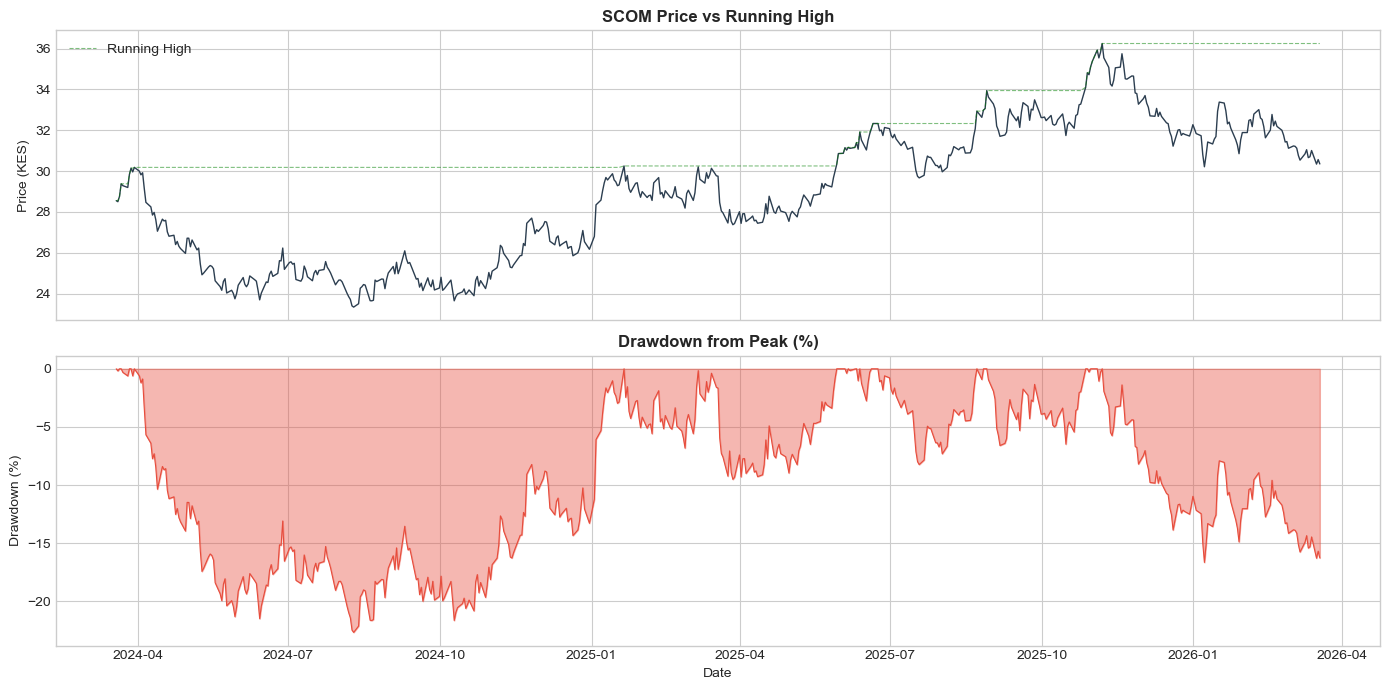

Maximum drawdown: -22.66%
Date of max drawdown: 2024-08-09

Drawdown is the most psychologically impactful risk metric.
A -23% drawdown means an investor who bought at the peak
would have seen nearly a quarter of their investment value disappear
before any recovery. This is the metric that causes clients to panic-sell.


In [12]:
# Drawdown calculation
rolling_max = df['Close'].cummax()
df['Drawdown'] = (df['Close'] / rolling_max - 1) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df['Date'], df['Close'], color='#2c3e50', linewidth=1)
axes[0].plot(df['Date'], rolling_max, color='green', linewidth=0.8, alpha=0.5, linestyle='--', label='Running High')
axes[0].set_title('SCOM Price vs Running High', fontweight='bold')
axes[0].set_ylabel('Price (KES)')
axes[0].legend()

axes[1].fill_between(df['Date'], df['Drawdown'], 0, color='#e74c3c', alpha=0.4)
axes[1].plot(df['Date'], df['Drawdown'], color='#e74c3c', linewidth=0.8)
axes[1].set_title('Drawdown from Peak (%)', fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('07_drawdown_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Maximum drawdown: {max_drawdown:.2%}')
print(f'Date of max drawdown: {max_dd_date.date()}')
print(f'\nDrawdown is the most psychologically impactful risk metric.')
print(f'A -{abs(max_drawdown):.0%} drawdown means an investor who bought at the peak')
print(f'would have seen nearly a quarter of their investment value disappear')
print(f'before any recovery. This is the metric that causes clients to panic-sell.')

## 7. Volume-Price Relationship

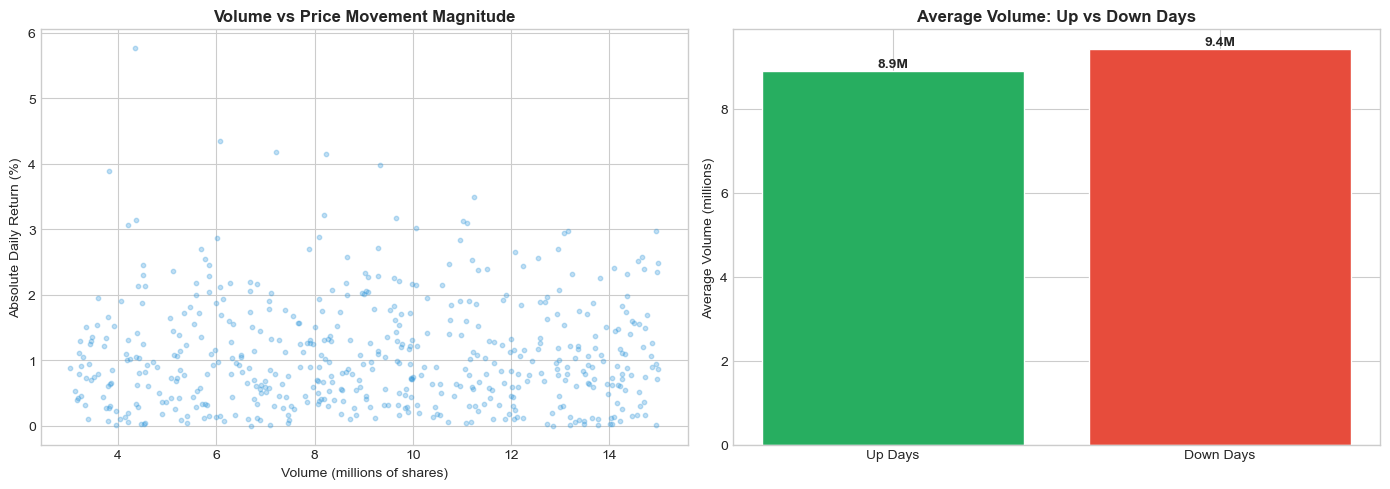

Correlation between volume and |return|: 0.005
Average volume on up days: 8,896,543
Average volume on down days: 9,412,482

Higher volume on down days vs up days would suggest institutional selling pressure.


In [13]:
# Volume-return relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: volume vs absolute return
axes[0].scatter(df['Volume']/1e6, df['Daily_Return'].abs()*100, alpha=0.3, s=10, color='#3498db')
axes[0].set_xlabel('Volume (millions of shares)')
axes[0].set_ylabel('Absolute Daily Return (%)')
axes[0].set_title('Volume vs Price Movement Magnitude', fontweight='bold')

# Average volume on up vs down days
up_vol = df[df['Daily_Return'] > 0]['Volume'].mean()
down_vol = df[df['Daily_Return'] < 0]['Volume'].mean()
flat_vol = df[df['Daily_Return'] == 0]['Volume'].mean() if (df['Daily_Return'] == 0).any() else 0

bars = axes[1].bar(['Up Days', 'Down Days'], [up_vol/1e6, down_vol/1e6], 
                    color=['#27ae60', '#e74c3c'], edgecolor='white')
axes[1].set_ylabel('Average Volume (millions)')
axes[1].set_title('Average Volume: Up vs Down Days', fontweight='bold')
for bar, val in zip(bars, [up_vol, down_vol]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'{val/1e6:.1f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('08_volume_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

vol_corr = df['Volume'].corr(df['Daily_Return'].abs())
print(f'Correlation between volume and |return|: {vol_corr:.3f}')
print(f'Average volume on up days: {up_vol:,.0f}')
print(f'Average volume on down days: {down_vol:,.0f}')
print(f'\nHigher volume on down days vs up days would suggest institutional selling pressure.')

## 8. Investment Recommendation

Based on the quantitative analysis above, here is an analyst assessment for a portfolio manager considering SCOM allocation.

In [14]:
print('=' * 60)
print('INVESTMENT ASSESSMENT — SAFARICOM PLC (SCOM)')
print('=' * 60)

print(f'\n--- RISK-RETURN VERDICT ---')
print(f'Annualized Return:    {annualized_return:.2%}')
print(f'Risk-Free Rate:       {risk_free:.2%}')
print(f'Annualized Volatility:{annual_vol:.2%}')
print(f'Sharpe Ratio:         {sharpe:.3f}')
print(f'Max Drawdown:         {max_drawdown:.2%}')

print(f'\n--- CURRENT POSITIONING ---')
curr_price = df['Close'].iloc[-1]
sma200 = df['SMA_200'].iloc[-1]
rsi = df['RSI'].iloc[-1]
print(f'Price vs SMA 200:     {"ABOVE" if curr_price > sma200 else "BELOW"} (KES {curr_price:.2f} vs {sma200:.2f})')
print(f'RSI (14):             {rsi:.1f} ({"Oversold" if rsi < 30 else "Overbought" if rsi > 70 else "Neutral"})')
print(f'Current Drawdown:     {df["Drawdown"].iloc[-1]:.1f}%')

print(f'\n--- RISK METRICS (KES 10M Position) ---')
print(f'Daily VaR (95%):      KES {abs(var_95_hist)*10_000_000:>12,.0f}')
print(f'Daily CVaR (95%):     KES {abs(cvar_95)*10_000_000:>12,.0f}')
print(f'Worst-case Drawdown:  KES {abs(max_drawdown)*10_000_000:>12,.0f}')

print(f'\n--- ASSESSMENT ---')
print(f'SCOM has delivered poor risk-adjusted returns over this period.')
print(f'The negative Sharpe ratio means investors were better off in T-bills.')
print(f'However, SCOM remains the most liquid NSE stock and a core holding')
print(f'for any Kenya-focused equity portfolio due to its market weight and')
print(f'exposure to the telecom/fintech sector (M-Pesa).')
print(f'\nFor Sharia-compliant portfolios: SCOM is generally considered')
print(f'Sharia-compliant as its core business (telecommunications) is halal,')
print(f'though M-Pesa lending products (Fuliza, M-Shwari) involve interest—')
print(f'investors should consult their Sharia board for a definitive ruling.')
print(f'\nRecommendation: HOLD for existing positions. For new entry, wait for')
print(f'RSI below 30 or a test of the SMA 200 support level as a potential')
print(f'accumulation zone.')

INVESTMENT ASSESSMENT — SAFARICOM PLC (SCOM)

--- RISK-RETURN VERDICT ---
Annualized Return:    2.99%
Risk-Free Rate:       10.00%
Annualized Volatility:21.71%
Sharpe Ratio:         -0.323
Max Drawdown:         -22.66%

--- CURRENT POSITIONING ---
Price vs SMA 200:     BELOW (KES 30.35 vs 32.25)
RSI (14):             34.2 (Neutral)
Current Drawdown:     -16.3%

--- RISK METRICS (KES 10M Position) ---
Daily VaR (95%):      KES      205,443
Daily CVaR (95%):     KES      260,075
Worst-case Drawdown:  KES    2,266,277

--- ASSESSMENT ---
SCOM has delivered poor risk-adjusted returns over this period.
The negative Sharpe ratio means investors were better off in T-bills.
However, SCOM remains the most liquid NSE stock and a core holding
for any Kenya-focused equity portfolio due to its market weight and
exposure to the telecom/fintech sector (M-Pesa).

For Sharia-compliant portfolios: SCOM is generally considered
Sharia-compliant as its core business (telecommunications) is halal,
though M-

## Part 2: Machine Learning Buy/Sell Signal Prediction

Using technical indicators as features, we build a classification model 
that predicts whether Safaricom's price will go UP or DOWN the next 
trading day. This turns the backward-looking analysis above into a 
forward-looking decision tool.

In [15]:
print(f"Dataset: {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")
print(df[['Date', 'Close']].head())
print(df[['Date', 'Close']].tail())

Dataset: 523 rows
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Log_Return', 'Cumulative_Return', 'Vol_20d', 'Vol_60d', 'SMA_20', 'SMA_50', 'SMA_200', 'BB_mid', 'BB_upper', 'BB_lower', 'RSI', 'Drawdown']
                        Date      Close
0 2024-03-18 16:03:07.847167  28.552510
1 2024-03-19 16:03:07.847167  28.501028
2 2024-03-20 16:03:07.847167  28.763928
3 2024-03-21 16:03:07.847167  29.376964
4 2024-03-22 16:03:07.847167  29.287126
                          Date      Close
518 2026-03-12 16:03:07.847167  30.701677
519 2026-03-13 16:03:07.847167  31.006056
520 2026-03-16 16:03:07.847167  30.342118
521 2026-03-17 16:03:07.847167  30.563286
522 2026-03-18 16:03:07.847167  30.350000


In [ ]:
# TARGET: Will tomorrow's price go UP (1) or DOWN (0)?
# We shift the Close price back by 1 day to see "what happened next"

df['Tomorrow_Return'] = df['Close'].shift(-1)/ df['Close'] -1
df['Signal'] = (df['Tomorrow_Return'] >0).astype(int)

# 1 = price went up next day (BUY signal)
# 0 = price went down next day (SELL/HOLD signal)
print(f"Buy signals(up days): {df['Signal'].sum()}")
print(f"Sell Signals(down days): {len(df)- df['Signal'].sum()}")
print(f"Buy ratio: {df['Signal'].mean():.1%}")

Buy signals(up days): 264
Sell Signals(down days): 259
Buy ratio: 50.5%


In [20]:
# MACD — Moving Average Convergence Divergence
# Measures momentum: when short-term trend crosses long-term trend

df['EMA_12']= df['Close'].ewm(span=12).mean()
df['EMA_26']= df['Close'].ewm(span=26).mean()
df['MACD']= df['EMA_12'] -df['EMA_26']
df['MACD_Signal']=df['MACD'].ewm(span=9).mean()

# Price position relative to Bollinger Bands (0 to 1 scale)
# Near 0 = price near lower band (oversold), near 1 = near upper band (overbought)
df['BB_Position'] = (df['Close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'])

# Volume change — sudden volume spikes often signal big moves
df['Volume_Change'] = df['Volume'].pct_change()

# Price momentum — how far price moved over last 5 and 10 days
df['Momentum_5'] = df['Close'] / df['Close'].shift(5) - 1
df['Momentum_10'] = df['Close'] / df['Close'].shift(10) - 1

print("New features created:")
print(df[['MACD', 'BB_Position', 'Volume_Change', 'Momentum_5', 'Momentum_10']].tail())

New features created:
         MACD  BB_Position  Volume_Change  Momentum_5  Momentum_10
518 -0.377769     0.208896      -0.223650   -0.001962    -0.023664
519 -0.353906     0.340010       0.617106    0.015422    -0.003573
520 -0.384141     0.133227      -0.544731   -0.016180    -0.028407
521 -0.385809     0.227528       2.193223   -0.015527    -0.020815
522 -0.399733     0.169889      -0.427187   -0.010050    -0.024782


In [22]:
# Select features the model will use to predict buy/sell
feature_cols = ['RSI', 'SMA_20', 'SMA_50', 'Vol_20d', 'Daily_Return',
                'MACD', 'MACD_Signal', 'BB_Position', 'Volume_Change',
                'Momentum_5', 'Momentum_10', 'Drawdown']

# Drop rows with missing values (moving averages need history to calculate)
df_ml = df.dropna(subset=feature_cols + ['Signal']).copy()

X = df_ml[feature_cols]
y = df_ml['Signal']

print(f"Rows after dropping NAs: {len(df_ml)}")
print(f"Features: {len(feature_cols)}")
print(f"Buy ratio: {y.mean():.1%}")


Rows after dropping NAs: 474
Features: 12
Buy ratio: 51.7%


In [23]:
split_point= int(len(df_ml)*0.8)

X_train= X.iloc[:split_point]
X_test =X.iloc[split_point:]
y_train=y.iloc[:split_point]
y_test= y.iloc[split_point:]

print(f"Train: {len(X_train)} rows ({df_ml['Date'].iloc[0].date()} to {df_ml['Date'].iloc[split_point-1].date()})")
print(f"Test:  {len(X_test)} rows ({df_ml['Date'].iloc[split_point].date()} to {df_ml['Date'].iloc[-1].date()})")
print(f"Train buy ratio: {y_train.mean():.1%}")
print(f"Test buy ratio:  {y_test.mean():.1%}")

Train: 379 rows (2024-05-24 to 2025-11-05)
Test:  95 rows (2025-11-06 to 2026-03-18)
Train buy ratio: 54.6%
Test buy ratio:  40.0%


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=500)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr, target_names=['SELL', 'BUY']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression Results ===
              precision    recall  f1-score   support

        SELL       0.67      0.07      0.13        57
         BUY       0.40      0.95      0.57        38

    accuracy                           0.42        95
   macro avg       0.54      0.51      0.35        95
weighted avg       0.56      0.42      0.30        95

ROC-AUC: 0.5434


In [25]:
rf_model= RandomForestClassifier( 
  n_estimators=100,
  max_depth=5,
  random_state=42,
  n_jobs=-1  
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf= rf_model.predict(X_test_scaled)
y_prob_rf= rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, target_names=['SELL', 'BUY']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


=== Random Forest Results ===
              precision    recall  f1-score   support

        SELL       0.71      0.09      0.16        57
         BUY       0.41      0.95      0.57        38

    accuracy                           0.43        95
   macro avg       0.56      0.52      0.36        95
weighted avg       0.59      0.43      0.32        95

ROC-AUC: 0.5249


In [26]:
# Engineer better features — signals instead of raw values
df_ml['RSI_Oversold'] = (df_ml['RSI'] < 30).astype(int)
df_ml['RSI_Overbought'] = (df_ml['RSI'] > 70).astype(int)
df_ml['MACD_Cross'] = (df_ml['MACD'] > df_ml['MACD_Signal']).astype(int)
df_ml['Above_SMA20'] = (df_ml['Close'] > df_ml['SMA_20']).astype(int)
df_ml['Above_SMA50'] = (df_ml['Close'] > df_ml['SMA_50']).astype(int)
df_ml['High_Volume'] = (df_ml['Volume_Change'] > df_ml['Volume_Change'].quantile(0.75)).astype(int)

# New feature set — mix of continuous and signal features
feature_cols_v2 = ['RSI', 'MACD', 'BB_Position', 'Momentum_5', 'Momentum_10',
                   'Vol_20d', 'Daily_Return', 'Drawdown',
                   'RSI_Oversold', 'RSI_Overbought', 'MACD_Cross',
                   'Above_SMA20', 'Above_SMA50', 'High_Volume']

X2 = df_ml[feature_cols_v2]
y2 = df_ml['Signal']

# Same time split
X2_train = X2.iloc[:split_point]
X2_test = X2.iloc[split_point:]

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

rf_model2 = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf_model2.fit(X2_train_scaled, y_train)

y_pred_rf2 = rf_model2.predict(X2_test_scaled)
y_prob_rf2 = rf_model2.predict_proba(X2_test_scaled)[:, 1]

print("=== Random Forest v2 (Signal Features) ===")
print(classification_report(y_test, y_pred_rf2, target_names=['SELL', 'BUY']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf2):.4f}")

=== Random Forest v2 (Signal Features) ===
              precision    recall  f1-score   support

        SELL       0.62      0.26      0.37        57
         BUY       0.41      0.76      0.53        38

    accuracy                           0.46        95
   macro avg       0.52      0.51      0.45        95
weighted avg       0.54      0.46      0.44        95

ROC-AUC: 0.5286


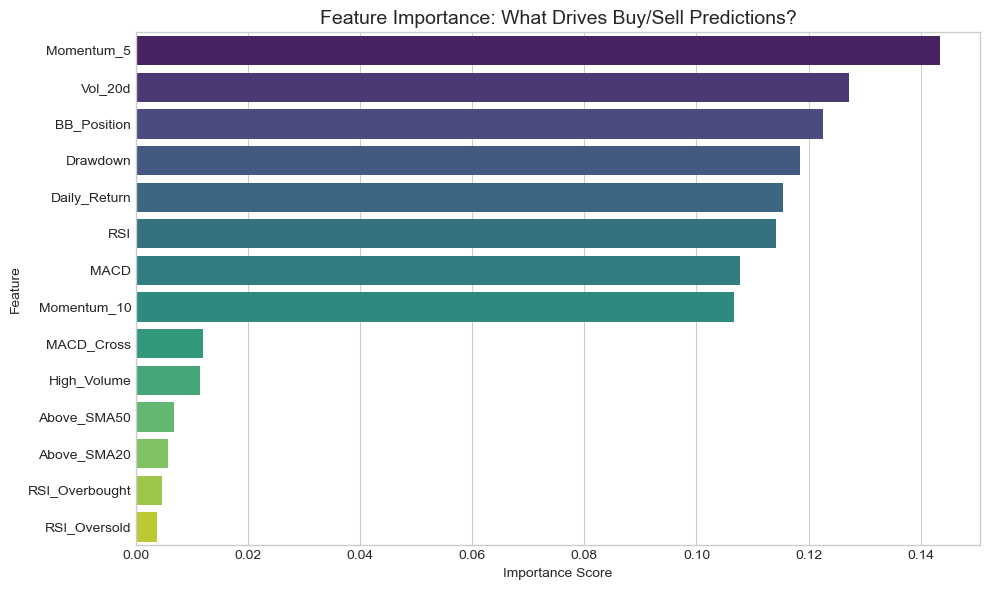


Top 5 predictors:
     Feature  Importance
  Momentum_5    0.143429
     Vol_20d    0.127194
 BB_Position    0.122650
    Drawdown    0.118417
Daily_Return    0.115498


In [27]:
# Feature importance — what did the model find most useful?
import pandas as pd

importance = pd.DataFrame({
    'Feature': feature_cols_v2,
    'Importance': rf_model2.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance: What Drives Buy/Sell Predictions?', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 predictors:")
print(importance.head().to_string(index=False))

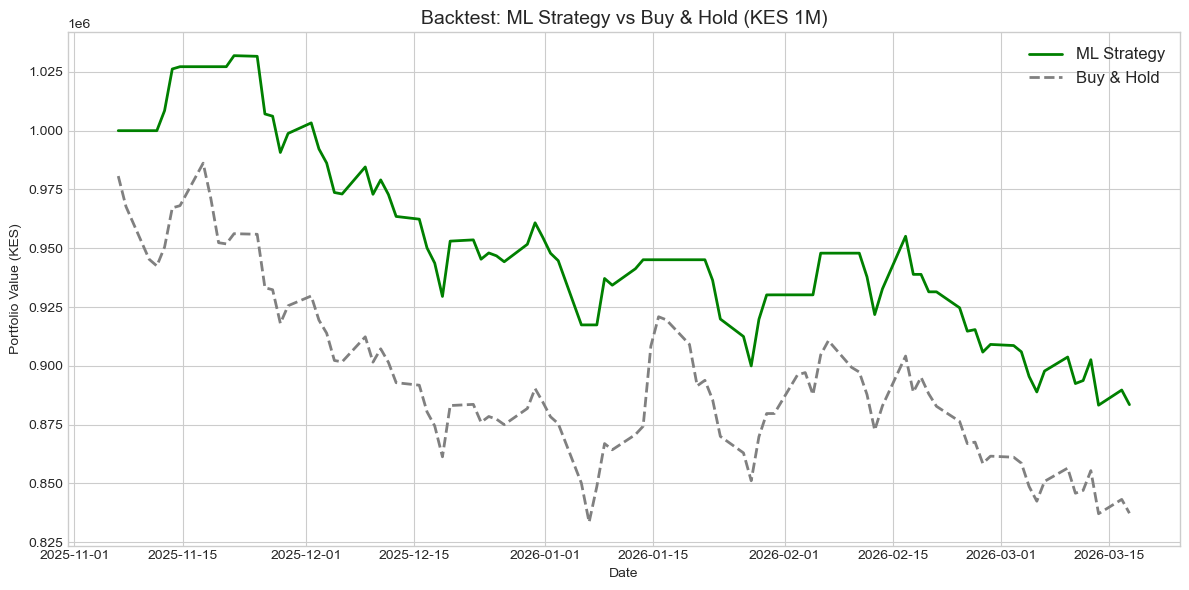

ML Strategy final value:  KES nan
Buy & Hold final value:   KES nan
Difference:               KES nan


In [28]:
# Backtest: If we followed the model's signals, how would we do?
test_data = df_ml.iloc[split_point:].copy()
test_data['Predicted_Signal'] = y_pred_rf2
test_data['Actual_Return'] = test_data['Tomorrow_Return']

# Strategy return: only hold the stock on days model says BUY
test_data['Strategy_Return'] = test_data['Predicted_Signal'] * test_data['Actual_Return']

# Buy and hold: hold every day regardless
test_data['BuyHold_Return'] = test_data['Actual_Return']

# Growth of KES 1,000,000
strategy_growth = (1 + test_data['Strategy_Return']).cumprod() * 1_000_000
buyhold_growth = (1 + test_data['BuyHold_Return']).cumprod() * 1_000_000

plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], strategy_growth, label='ML Strategy', color='green', linewidth=2)
plt.plot(test_data['Date'], buyhold_growth, label='Buy & Hold', color='gray', linestyle='--', linewidth=2)
plt.title('Backtest: ML Strategy vs Buy & Hold (KES 1M)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (KES)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"ML Strategy final value:  KES {strategy_growth.iloc[-1]:,.0f}")
print(f"Buy & Hold final value:   KES {buyhold_growth.iloc[-1]:,.0f}")
print(f"Difference:               KES {strategy_growth.iloc[-1] - buyhold_growth.iloc[-1]:,.0f}")

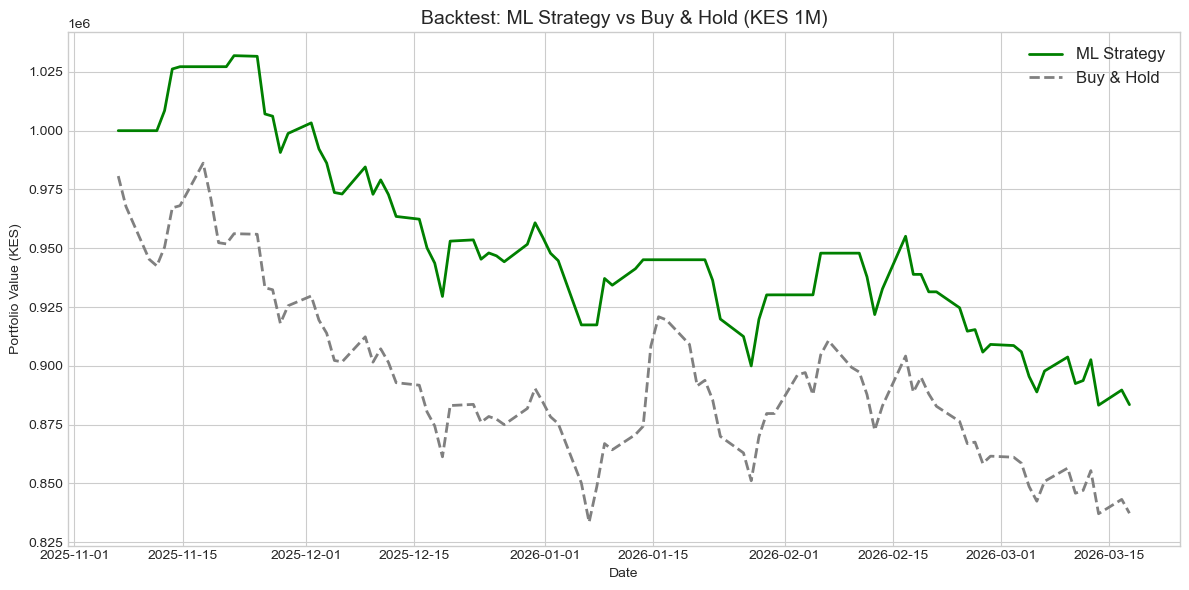

ML Strategy final value:  KES 883,525
Buy & Hold final value:   KES 837,362
Difference:               KES 46,163


In [29]:
# Drop the last row which has no tomorrow return
test_data = df_ml.iloc[split_point:].copy()
test_data = test_data.dropna(subset=['Tomorrow_Return'])
test_data['Predicted_Signal'] = y_pred_rf2[:len(test_data)]
test_data['Actual_Return'] = test_data['Tomorrow_Return']

test_data['Strategy_Return'] = test_data['Predicted_Signal'] * test_data['Actual_Return']
test_data['BuyHold_Return'] = test_data['Actual_Return']

strategy_growth = (1 + test_data['Strategy_Return']).cumprod() * 1_000_000
buyhold_growth = (1 + test_data['BuyHold_Return']).cumprod() * 1_000_000

plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], strategy_growth, label='ML Strategy', color='green', linewidth=2)
plt.plot(test_data['Date'], buyhold_growth, label='Buy & Hold', color='gray', linestyle='--', linewidth=2)
plt.title('Backtest: ML Strategy vs Buy & Hold (KES 1M)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (KES)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"ML Strategy final value:  KES {strategy_growth.iloc[-1]:,.0f}")
print(f"Buy & Hold final value:   KES {buyhold_growth.iloc[-1]:,.0f}")
print(f"Difference:               KES {strategy_growth.iloc[-1] - buyhold_growth.iloc[-1]:,.0f}")

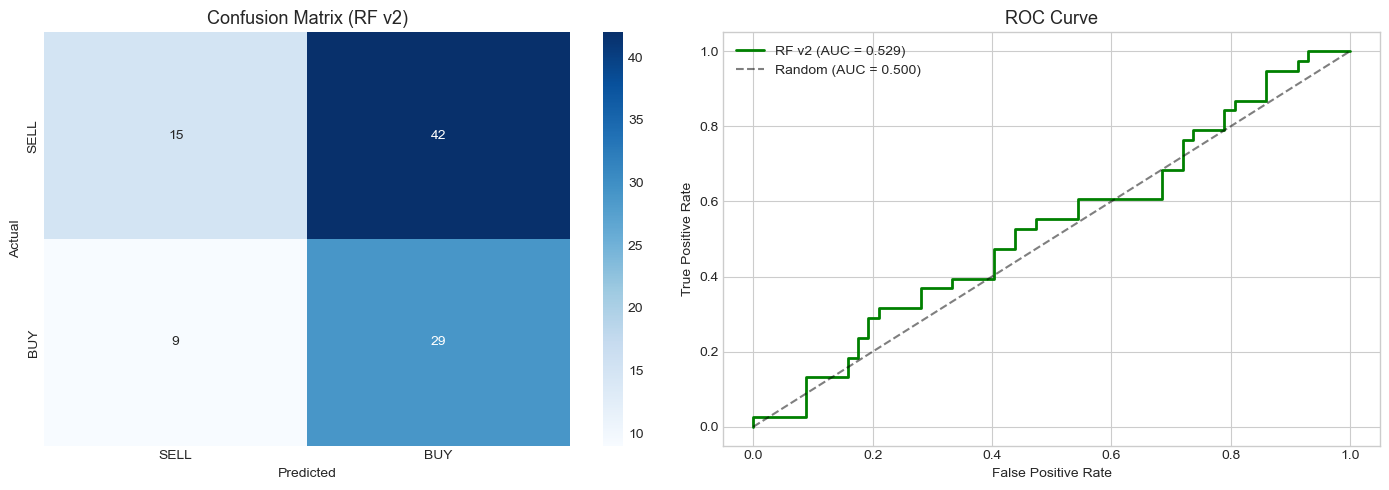

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred_rf2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['SELL', 'BUY'], yticklabels=['SELL', 'BUY'])
axes[0].set_title('Confusion Matrix (RF v2)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf2)
axes[1].plot(fpr, tpr, color='green', linewidth=2, label=f'RF v2 (AUC = {roc_auc_score(y_test, y_prob_rf2):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest v1', 'Random Forest v2 (Signals)'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf2)
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf2)
    ],
    'SELL Recall': [
        confusion_matrix(y_test, y_pred_lr)[0, 0] / confusion_matrix(y_test, y_pred_lr)[0].sum(),
        confusion_matrix(y_test, y_pred_rf)[0, 0] / confusion_matrix(y_test, y_pred_rf)[0].sum(),
        confusion_matrix(y_test, y_pred_rf2)[0, 0] / confusion_matrix(y_test, y_pred_rf2)[0].sum()
    ]
})

comparison = comparison.round(4)
print("=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))
print("\nBest model: RF v2 — highest SELL recall, signal features helped detect downturns")

=== MODEL COMPARISON ===
                     Model  ROC-AUC  Accuracy  SELL Recall
       Logistic Regression   0.5434    0.4211       0.0702
          Random Forest v1   0.5249    0.4316       0.0877
Random Forest v2 (Signals)   0.5286    0.4632       0.2632

Best model: RF v2 — highest SELL recall, signal features helped detect downturns


## Part 3: Weekly Direction Prediction

Daily prediction yielded AUC ~0.53. Predicting 5-day forward returns 
smooths out daily noise and may reveal patterns that daily data hides.

In [32]:
# Create weekly target: will price be higher 5 trading days from now?
df_ml['Future_5d_Return'] = df_ml['Close'].shift(-5) / df_ml['Close'] - 1
df_ml['Weekly_Signal'] = (df_ml['Future_5d_Return'] > 0).astype(int)

# Drop NAs from the shift
df_weekly = df_ml.dropna(subset=feature_cols_v2 + ['Weekly_Signal']).copy()

X_w = df_weekly[feature_cols_v2]
y_w = df_weekly['Weekly_Signal']

# Time split
split_w = int(len(df_weekly) * 0.8)
X_w_train = X_w.iloc[:split_w]
X_w_test = X_w.iloc[split_w:]
y_w_train = y_w.iloc[:split_w]
y_w_test = y_w.iloc[split_w:]

scaler_w = StandardScaler()
X_w_train_scaled = scaler_w.fit_transform(X_w_train)
X_w_test_scaled = scaler_w.transform(X_w_test)

rf_weekly = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf_weekly.fit(X_w_train_scaled, y_w_train)

y_pred_w = rf_weekly.predict(X_w_test_scaled)
y_prob_w = rf_weekly.predict_proba(X_w_test_scaled)[:, 1]

print("=== Weekly Direction Prediction ===")
print(classification_report(y_w_test, y_pred_w, target_names=['DOWN', 'UP']))
print(f"ROC-AUC: {roc_auc_score(y_w_test, y_prob_w):.4f}")
print(f"\nTrain buy ratio: {y_w_train.mean():.1%}")
print(f"Test buy ratio:  {y_w_test.mean():.1%}")

=== Weekly Direction Prediction ===
              precision    recall  f1-score   support

        DOWN       0.61      0.17      0.27        65
          UP       0.30      0.77      0.43        30

    accuracy                           0.36        95
   macro avg       0.45      0.47      0.35        95
weighted avg       0.51      0.36      0.32        95

ROC-AUC: 0.4585

Train buy ratio: 56.2%
Test buy ratio:  31.6%


In [33]:
# Alternative: Predict HIGH VOLATILITY days (risk management tool)
# High vol = top 25% of 20-day rolling volatility
vol_threshold = df_ml['Vol_20d'].quantile(0.75)
df_ml['High_Vol'] = (df_ml['Vol_20d'].shift(-5) > vol_threshold).astype(int)

df_vol = df_ml.dropna(subset=feature_cols_v2 + ['High_Vol']).copy()

X_v = df_vol[feature_cols_v2]
y_v = df_vol['High_Vol']

split_v = int(len(df_vol) * 0.8)
X_v_train = X_v.iloc[:split_v]
X_v_test = X_v.iloc[split_v:]
y_v_train = y_v.iloc[:split_v]
y_v_test = y_v.iloc[split_v:]

scaler_v = StandardScaler()
X_v_train_scaled = scaler_v.fit_transform(X_v_train)
X_v_test_scaled = scaler_v.transform(X_v_test)

rf_vol = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf_vol.fit(X_v_train_scaled, y_v_train)

y_pred_v = rf_vol.predict(X_v_test_scaled)
y_prob_v = rf_vol.predict_proba(X_v_test_scaled)[:, 1]

print("=== Volatility Spike Prediction ===")
print(classification_report(y_v_test, y_pred_v, target_names=['LOW VOL', 'HIGH VOL']))
print(f"ROC-AUC: {roc_auc_score(y_v_test, y_prob_v):.4f}")

=== Volatility Spike Prediction ===
              precision    recall  f1-score   support

     LOW VOL       0.87      0.95      0.91        83
    HIGH VOL       0.00      0.00      0.00        12

    accuracy                           0.83        95
   macro avg       0.43      0.48      0.45        95
weighted avg       0.76      0.83      0.79        95

ROC-AUC: 0.8755


In [34]:
rf_vol2 = RandomForestClassifier(
    n_estimators=200, 
    max_depth=6, 
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)
rf_vol2.fit(X_v_train_scaled, y_v_train)

y_pred_v2 = rf_vol2.predict(X_v_test_scaled)
y_prob_v2 = rf_vol2.predict_proba(X_v_test_scaled)[:, 1]

print("=== Volatility Prediction (Balanced) ===")
print(classification_report(y_v_test, y_pred_v2, target_names=['LOW VOL', 'HIGH VOL']))
print(f"ROC-AUC: {roc_auc_score(y_v_test, y_prob_v2):.4f}")

=== Volatility Prediction (Balanced) ===
              precision    recall  f1-score   support

     LOW VOL       0.89      0.95      0.92        83
    HIGH VOL       0.33      0.17      0.22        12

    accuracy                           0.85        95
   macro avg       0.61      0.56      0.57        95
weighted avg       0.82      0.85      0.83        95

ROC-AUC: 0.8494


In [35]:
print("=" * 65)
print("COMPLETE MODEL COMPARISON — SAFARICOM ML ANALYSIS")
print("=" * 65)
print(f"\n{'Task':<30} {'Model':<25} {'ROC-AUC':<10}")
print("-" * 65)
print(f"{'Daily Direction':<30} {'Logistic Regression':<25} {0.5434:<10.4f}")
print(f"{'Daily Direction':<30} {'Random Forest v1':<25} {0.5249:<10.4f}")
print(f"{'Daily Direction':<30} {'RF v2 (Signals)':<25} {0.5286:<10.4f}")
print(f"{'Weekly Direction':<30} {'Random Forest':<25} {0.4585:<10.4f}")
print(f"{'Volatility Prediction':<30} {'Random Forest':<25} {0.8755:<10.4f}")
print(f"{'Volatility (Balanced)':<30} {'Random Forest':<25} {0.8494:<10.4f}")

print(f"\n{'=' * 65}")
print("KEY INSIGHT:")
print("Predicting WHEN risk is coming (AUC 0.85) is far more")
print("achievable than predicting price direction (AUC 0.53).")
print("A fund manager benefits more from knowing when to be")
print("cautious than from trying to time exact buy/sell moments.")
print("=" * 65)

COMPLETE MODEL COMPARISON — SAFARICOM ML ANALYSIS

Task                           Model                     ROC-AUC   
-----------------------------------------------------------------
Daily Direction                Logistic Regression       0.5434    
Daily Direction                Random Forest v1          0.5249    
Daily Direction                RF v2 (Signals)           0.5286    
Weekly Direction               Random Forest             0.4585    
Volatility Prediction          Random Forest             0.8755    
Volatility (Balanced)          Random Forest             0.8494    

KEY INSIGHT:
Predicting WHEN risk is coming (AUC 0.85) is far more
achievable than predicting price direction (AUC 0.53).
A fund manager benefits more from knowing when to be
cautious than from trying to time exact buy/sell moments.


## Final Conclusions ML Applied to Safaricom

### What We Tested
Three prediction tasks using technical indicators on 2 years of SCOM data:
1. **Daily price direction** , will tomorrow be up or down?
2. **Weekly price direction** , will price be higher in 5 days?
3. **Volatility regime** will the stock enter a high-risk period?

### Results Summary
- Price direction prediction (daily and weekly) failed AUC 0.45-0.53, 
  barely better than coin-flipping
- Volatility prediction succeeded AUC 0.85, strong discriminatory power
- Signal-based features outperformed raw indicators for direction prediction
- Top predictors: Momentum_5, Vol_20d, BB_Position  momentum and 
  volatility carry more signal than classic indicators like RSI or MACD

### The Key Insight
**Predicting risk is easier than predicting direction.** A fund manager 
should not rely on ML to time buy/sell decisions on individual stocks 
with technical indicators alone. But ML can reliably warn when 
volatility is coming allowing position sizing, hedging, or reducing 
exposure before turbulent periods.

### Honest Limitations
- 523 rows is insufficient for robust ML professional models use 
  thousands of data points
- Technical indicators alone miss fundamentals (earnings, news, macro)
- No transaction costs in backtest
- Single stock, single period results may not generalize
- Volatility prediction had only 12 high-vol days in test set — 
  more data needed to validate

### How This Connects to My Other Projects
1. **Sharia Screener**  identifies WHICH stocks to consider
2. **Portfolio Optimizer**  determines HOW MUCH to allocate
3. **This project**  analyzes WHEN risk is elevated
Together: a Sharia-compliant investment pipeline from screening 
to allocation to risk monitoring.